In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 데이터셋 불러오기
df=pd.read_csv('/Users/bluecloud/Documents/대학/유런/데이터셋/job_clean.csv')
df.head(10)

,job_title,job_category,salary_in_usd,experience_level,employment_type,work_setting,company_location,company_size,job_group,companyLoc_group
0,Data DevOps Engineer,Data Engineering,95012,Mid-level,Full-time,Hybrid,Germany,L,2,etc
1,Data Architect,Data Architecture and Modeling,186000,Senior,Full-time,In-person,United States,M,2,United States
2,Data Architect,Data Architecture and Modeling,81800,Senior,Full-time,In-person,United States,M,2,United States
3,Data Scientist,Data Science and Research,212000,Senior,Full-time,In-person,United States,M,2,United States
4,Data Scientist,Data Science and Research,93300,Senior,Full-time,In-person,United States,M,2,United States
5,Data Scientist,Data Science and Research,130000,Senior,Full-time,Remote,United States,M,2,United States
6,Data Scientist,Data Science and Research,100000,Senior,Full-time,Remote,United States,M,2,United States
7,Machine Learning Researcher,Machine Learning and AI,224400,Mid-level,Full-time,In-person,United States,M,2,United States
8,Machine Learning Researcher,Machine Learning and AI,138700,Mid-level,Full-time,In-person,United States,M,2,United States
9,Data Engineer,Data Engineering,210000,Executive,Full-time,Remote,United States,M,2,United States


# 1. 추가적인 전처리

In [3]:
# 칼럼 제거하기
drop_columns = ['company_location', 'job_category']
df.drop(drop_columns, axis=1, inplace=True)

In [5]:
df.head(10)

,job_title,salary_in_usd,experience_level,employment_type,work_setting,company_size,job_group,companyLoc_group
0,Data DevOps Engineer,95012,Mid-level,Full-time,Hybrid,L,2,etc
1,Data Architect,186000,Senior,Full-time,In-person,M,2,United States
2,Data Architect,81800,Senior,Full-time,In-person,M,2,United States
3,Data Scientist,212000,Senior,Full-time,In-person,M,2,United States
4,Data Scientist,93300,Senior,Full-time,In-person,M,2,United States
5,Data Scientist,130000,Senior,Full-time,Remote,M,2,United States
6,Data Scientist,100000,Senior,Full-time,Remote,M,2,United States
7,Machine Learning Researcher,224400,Mid-level,Full-time,In-person,M,2,United States
8,Machine Learning Researcher,138700,Mid-level,Full-time,In-person,M,2,United States
9,Data Engineer,210000,Executive,Full-time,Remote,M,2,United States


### 인코딩

In [7]:
# 순서 꼬임 이슈로 LabelEncoding이 아닌 map으로 인코딩
# 해당 라벨인코딩 순서
experience_order = {'Entry-level' : 0, 'Mid-level' : 1, 'Senior' : 2, 'Executive' : 3}
company_size_order = {'S' : 0, 'M': 1, 'L' : 2}

# 적용 
df['experience_level']=df['experience_level'].map(experience_order)
df['company_size']=df['company_size'].map(company_size_order)

df.head(10)

,job_title,salary_in_usd,experience_level,employment_type,work_setting,company_size,job_group,companyLoc_group
0,Data DevOps Engineer,95012,1,Full-time,Hybrid,2,2,etc
1,Data Architect,186000,2,Full-time,In-person,1,2,United States
2,Data Architect,81800,2,Full-time,In-person,1,2,United States
3,Data Scientist,212000,2,Full-time,In-person,1,2,United States
4,Data Scientist,93300,2,Full-time,In-person,1,2,United States
5,Data Scientist,130000,2,Full-time,Remote,1,2,United States
6,Data Scientist,100000,2,Full-time,Remote,1,2,United States
7,Machine Learning Researcher,224400,1,Full-time,In-person,1,2,United States
8,Machine Learning Researcher,138700,1,Full-time,In-person,1,2,United States
9,Data Engineer,210000,3,Full-time,Remote,1,2,United States


In [9]:
# 원-핫 인코딩 적용할 피처
ohe_features = ["job_group","job_title", "employment_type", "work_setting","companyLoc_group"]
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(df[ohe_features])
X_ohe = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(ohe_features))

In [13]:
#원래 데이터 프레임과 결합
#dropfirst하기
df=df.drop(ohe_features,axis=1)
df=pd.concat([df,X_ohe],axis=1)

In [15]:
df.shape

(7453, 127)

In [17]:
df.head(10)

,salary_in_usd,experience_level,company_size,job_group_0,job_group_1,job_group_2,job_title_AI Architect,job_title_AI Developer,job_title_AI Engineer,job_title_AI Programmer,...,employment_type_Freelance,employment_type_Full-time,employment_type_Part-time,work_setting_Hybrid,work_setting_In-person,work_setting_Remote,companyLoc_group_Canada,companyLoc_group_United Kingdom,companyLoc_group_United States,companyLoc_group_etc
0,95012,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,186000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,81800,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,212000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,93300,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5,130000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6,100000,2,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,224400,1,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8,138700,1,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9,210000,3,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# 2. 모델 학습 및 평가

### 2-1. 데이터 분할

In [20]:
y=df['salary_in_usd']
X=df.drop('salary_in_usd',axis=1,inplace=False)

#데이터 분할 8:2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156)

### 2-2. 모델 학습 및 평가 함수

In [22]:
# 모델 학습 및 평가 함수
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {"MAE": mae, "MSE":mse,"RMSE": rmse, "R2 Score": r2}

### 2-3. 모델별 평가 수행

In [24]:
rf=RandomForestRegressor(random_state=42)
gb=GradientBoostingRegressor(random_state=42)

rf_results=train_and_evaluate(rf, X_train, X_test, y_train, y_test)
gb_results=train_and_evaluate(gb, X_train, X_test, y_train, y_test)

print("랜덤 포레스트 결과",rf_results)
print("그래디언트부스트 결과",gb_results)

랜덤 포레스트 결과 {'MAE': 39181.95971691012, 'MSE': 2626451821.62571, 'RMSE': 51248.92019960723, 'R2 Score': 0.31524858654286847}
그래디언트부스트 결과 {'MAE': 39412.62332965222, 'MSE': 2603729181.190942, 'RMSE': 51026.74966320059, 'R2 Score': 0.321172685369686}


# 3. 튜닝의 끝은 순정

### 3-1. 이상치 제거

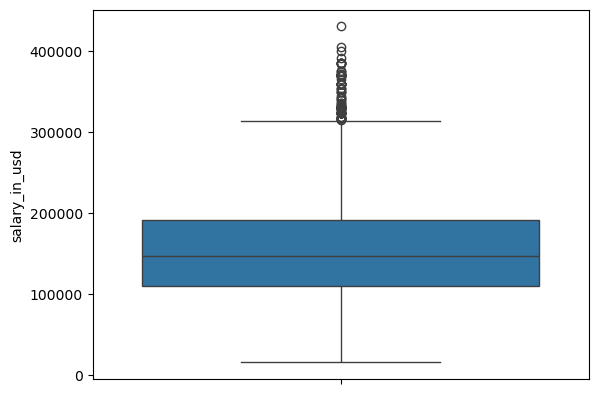

In [26]:
# 이상치 탐색 및 제거
sns.boxplot(y=df["salary_in_usd"])
plt.show()
q1 = df["salary_in_usd"].quantile(0.25)
q3 = df["salary_in_usd"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df = df[(df["salary_in_usd"] >= lower_bound) & (df["salary_in_usd"] <= upper_bound)]

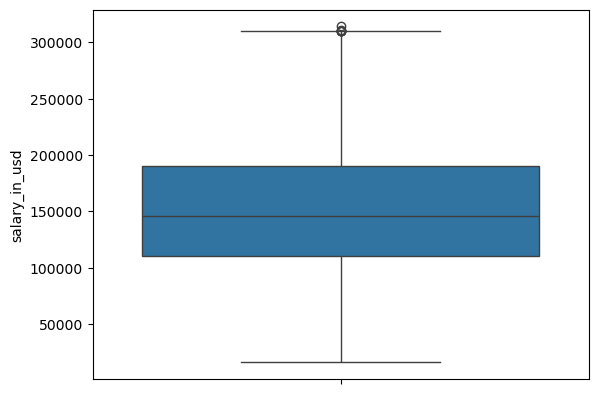

In [28]:
y=df['salary_in_usd']
sns.boxplot(y=y)
plt.show()

In [32]:
X=df.drop('salary_in_usd',axis=1,inplace=False)
y=df['salary_in_usd']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156)

### 3-2.feature_importances로 파악하기

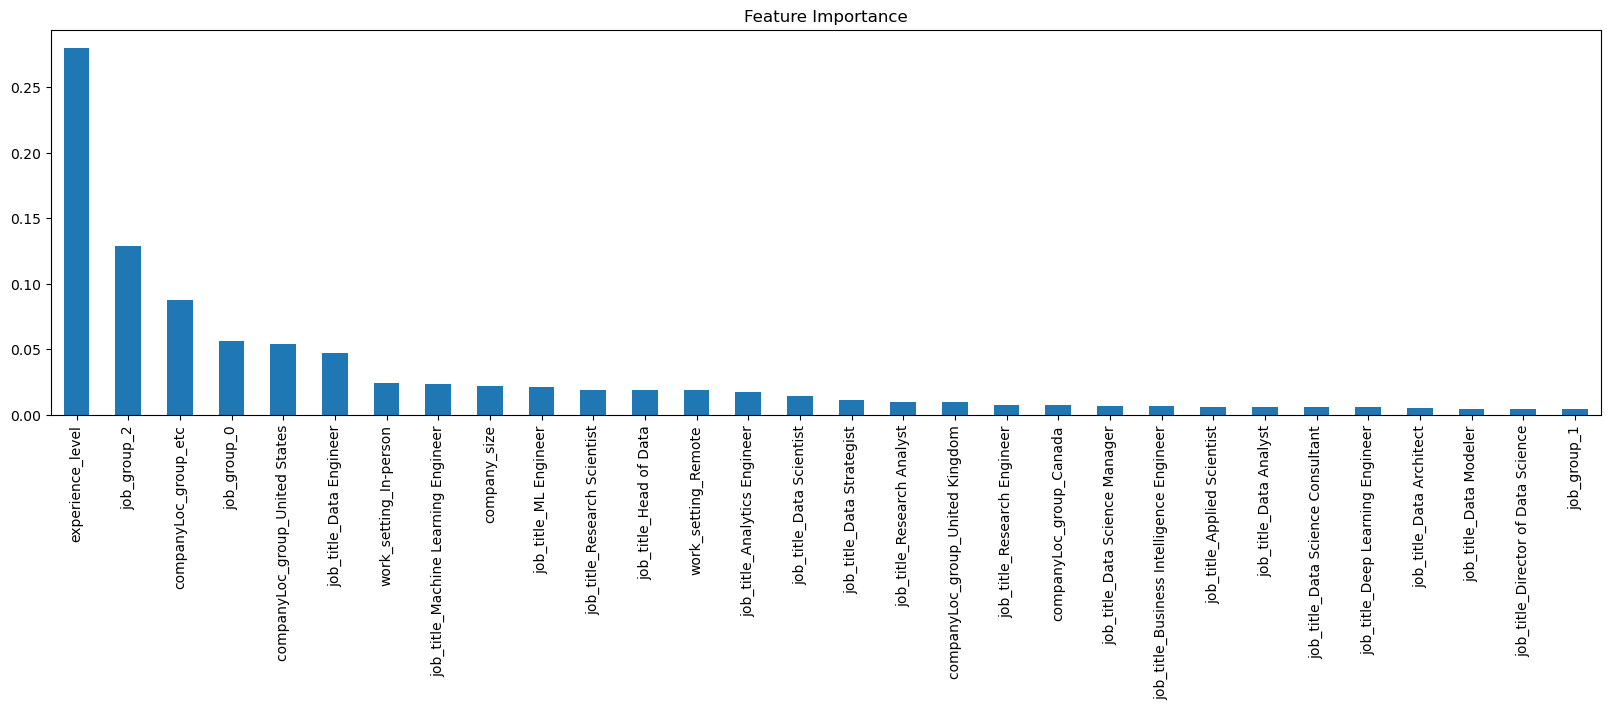

In [34]:
# 랜덤포레스트 중요도 시각화
rf_feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_feature_importances.sort_values(ascending=False)[:30].plot(kind='bar', figsize=(20,5))
plt.title("Feature Importance")
plt.show()

In [36]:
# 랜덤포레스트 피처 중요도
rf_feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
print(rf_feature_importances.sort_values(ascending=False)[:30])

experience_level                            0.279816
job_group_2                                 0.128901
companyLoc_group_etc                        0.087553
job_group_0                                 0.056582
companyLoc_group_United States              0.054076
job_title_Data Engineer                     0.046901
work_setting_In-person                      0.024092
job_title_Machine Learning Engineer         0.023014
company_size                                0.022227
job_title_ML Engineer                       0.021300
job_title_Research Scientist                0.019148
job_title_Head of Data                      0.018951
work_setting_Remote                         0.018885
job_title_Analytics Engineer                0.017659
job_title_Data Scientist                    0.014057
job_title_Data Strategist                   0.010951
job_title_Research Analyst                  0.009901
companyLoc_group_United Kingdom             0.009850
job_title_Research Engineer                 0.

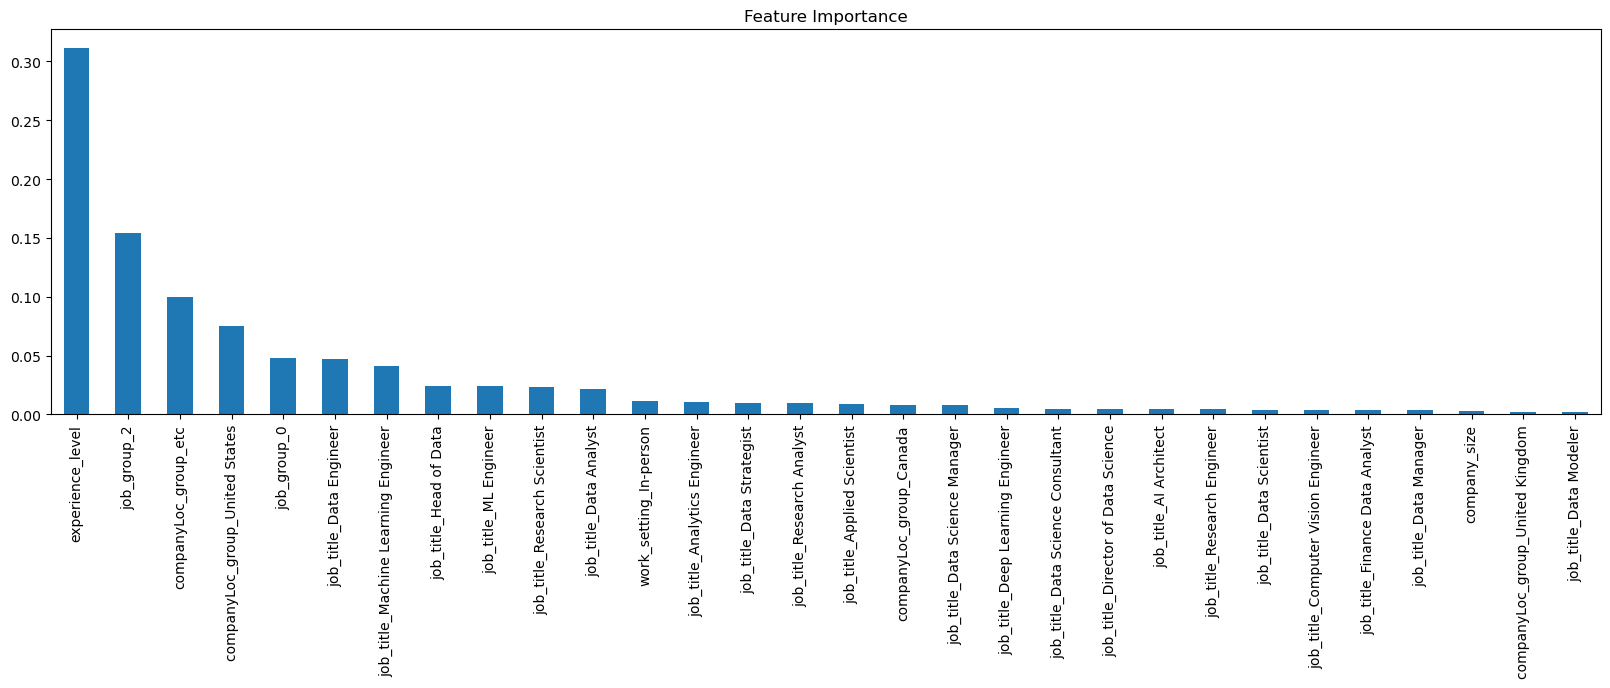

In [38]:
# GradientBoost 중요도 시각화
gb_feature_importances = pd.Series(gb.feature_importances_, index=X_train.columns)
gb_feature_importances.sort_values(ascending=False)[:30].plot(kind='bar', figsize=(20,5))
plt.title("Feature Importance")
plt.show()

In [40]:
# GradientBoost 피처 중요도
gb_feature_importances = pd.Series(gb.feature_importances_, index=X_train.columns)
print(gb_feature_importances.sort_values(ascending=False)[:30])

experience_level                       0.311691
job_group_2                            0.153964
companyLoc_group_etc                   0.099467
companyLoc_group_United States         0.075141
job_group_0                            0.048285
job_title_Data Engineer                0.047033
job_title_Machine Learning Engineer    0.040971
job_title_Head of Data                 0.024301
job_title_ML Engineer                  0.023865
job_title_Research Scientist           0.023015
job_title_Data Analyst                 0.021885
work_setting_In-person                 0.011395
job_title_Analytics Engineer           0.010856
job_title_Data Strategist              0.010059
job_title_Research Analyst             0.009940
job_title_Applied Scientist            0.008845
companyLoc_group_Canada                0.007908
job_title_Data Science Manager         0.007812
job_title_Deep Learning Engineer       0.005224
job_title_Data Science Consultant      0.004958
job_title_Director of Data Science     0

### 3-3. 각 모델별로 Feature Selection을 따로 진행(0.01초과)

In [42]:
# 랜덤포레스트 기반 Feature Selection
important_features_rf = rf_feature_importances[rf_feature_importances > 0.01].index
X_train_rf = X_train[important_features_rf]
X_test_rf = X_test[important_features_rf]

# 그래디언트 부스팅 기반 Feature Selection
important_features_gb = gb_feature_importances[gb_feature_importances > 0.01].index
X_train_gb = X_train[important_features_gb]
X_test_gb = X_test[important_features_gb]

In [44]:
rf=RandomForestRegressor(random_state=42)
gb=GradientBoostingRegressor(random_state=42)

rf_results_2=train_and_evaluate(rf, X_train_rf, X_test_rf, y_train, y_test)
gb_results_2=train_and_evaluate(gb, X_train_gb, X_test_gb, y_train, y_test)

print("랜덤 포레스트 결과2",rf_results_2)
print("그래디언트부스트 결과2",gb_results_2)

랜덤 포레스트 결과2 {'MAE': 39675.67215372039, 'MSE': 2508752508.41548, 'RMSE': 50087.44861155817, 'R2 Score': 0.30798627088504205}
그래디언트부스트 결과2 {'MAE': 39381.82003789103, 'MSE': 2476552912.759936, 'RMSE': 49764.97676840547, 'R2 Score': 0.31686820012710204}


# 4. 하이퍼 파라미터 튜닝

### 4-1. 랜포

In [46]:
from sklearn.model_selection import GridSearchCV

rf_params={
    "n_estimators": [100, 200, 300],  
    "max_depth": [6, 8, 10, 12,20],  
    "min_samples_split": [2, 5, 8,10],  
    "min_samples_leaf": [1, 2, 4,8]
}

#GridSearchCV 실행
rf_grid=GridSearchCV(rf,param_grid=rf_params,cv=3,n_jobs=-1)
rf_grid.fit(X_train_rf,y_train)

# 최적의 파라미터
print('최적의 하이퍼 파라미터:\n',rf_grid.best_params_)
print('최고 예측 정확도:{0:.4f}'.format(rf_grid.best_score_))

최적의 하이퍼 파라미터:
 {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
최고 예측 정확도:0.3225


### 4-2.그래디언트

In [48]:
gb_params = {
    "n_estimators": [100, 200, 300],  
    "learning_rate": [0.01, 0.05, 0.1],  
    "max_depth": [3, 5, 7],  
    "subsample": [0.8, 1.0]
}

# GridSearchCV 실행
gb_grid = GridSearchCV(gb, gb_params, cv=3, n_jobs=-1)
gb_grid.fit(X_train_gb, y_train)

# 최적 하이퍼파라미터 
print("최적의 하이퍼 파라미터", gb_grid.best_params_)
print('최고 예측 정확도:{0:.4f}'.format(gb_grid.best_score_))

최적의 하이퍼 파라미터 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
최고 예측 정확도:0.3240


# 5. 모델 학습 및 평가 again

In [50]:
# 최적 모델 of Rf
best_rf=rf_grid.best_estimator_
rf_results_3=train_and_evaluate(best_rf,X_train_rf, X_test_rf, y_train, y_test)
# 최적 모델 of Gb
best_gb=gb_grid.best_estimator_
gb_results_3=train_and_evaluate(best_gb,X_train_gb, X_test_gb, y_train, y_test)

print("랜덤 포레스트 결과3",rf_results_3)
print("그래디언트부스트 결과3",gb_results_3)

랜덤 포레스트 결과3 {'MAE': 39501.510559873066, 'MSE': 2480032547.0370603, 'RMSE': 49799.925170998606, 'R2 Score': 0.31590837858871135}
그래디언트부스트 결과3 {'MAE': 39368.11890032843, 'MSE': 2483810876.197188, 'RMSE': 49837.84582219809, 'R2 Score': 0.3148661651208011}
